# Bibs & Configs

In [1]:
import pandas as pd
import numpy as np
import os
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, average_precision_score,
                             balanced_accuracy_score, roc_auc_score, confusion_matrix)
from sklearn.utils.class_weight import compute_sample_weight
from imblearn.metrics import geometric_mean_score

# Configs
split_path = '../data/split'
seed = 2025

import warnings, time
warnings.filterwarnings("ignore", message=".*does not have valid feature names.*", category=UserWarning)

In [2]:
df = pd.read_csv(os.path.join(split_path, 'train_val_set.csv'))
print(df.shape)

df.head()

(7420, 7)


,id,title,author,publication_date,summary,label,fold
0,620,animal farm,george orwell,1945.0,old major the old boar on the manor farm calls...,0,fold_3
1,843,a clockwork orange,anthony burgess,1962.0,alex a teenager living in nearfuture england l...,0,fold_2
2,986,the plague,albert camus,1947.0,the text of the plague is divided into five pa...,0,fold_1
3,2080,a fire upon the deep,vernor vinge,NaN,the novel posits that space around the milky w...,0,fold_4
4,4082,blade runner 2 the edge of human,k w jeter,1995.0,beginning several months after the events in b...,0,fold_5


In [3]:
# Abordagem textual
def essencial_columns(df):
    df['text'] = df['title'] + ' ' + df['summary']
    return df[['text','fold','label']]

df = essencial_columns(df)
df.head()

,text,fold,label
0,animal farm old major the old boar on the mano...,fold_3,0
1,a clockwork orange alex a teenager living in n...,fold_2,0
2,the plague the text of the plague is divided i...,fold_1,0
3,a fire upon the deep the novel posits that spa...,fold_4,0
4,blade runner 2 the edge of human beginning sev...,fold_5,0


# Critérios de atendimento
- num de amostras > 500 -> ok
- 2 ou mais classes -> ok
- nro de features > 100 -> ok (pensando em um TFIDF ou Bag of words, cada palavra é uma feature)
    - O modo std do CountVectorizer ignora alguns tokens (que tipicamente são ignorados mesmo)
        - Como contar esses ignorados é indiferente, apenas será mostrado que a ordem de grandeza das features aqui é da ordem de mil vezes o mínimo estipulado

In [4]:
num_classes = df['label'].nunique()
print(f'Número de classes: {num_classes}')

# Medição do tamanho do vocabulário
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df['text'])
vocab_size = len(vectorizer.get_feature_names_out())
print(f'Tamanho do vocabulário: {vocab_size}')

Número de classes: 2
Tamanho do vocabulário: 101198


# Procedimento treinamento
- Obviamente, não é esperado bons resultados com uma abordagem direta, mas isso será verificado para termos uma comparação.
    - Muitos problemas são observados aqui:
        - Extremo desbalanceamento
        - Altissimo numero de features (maior que o de amostras)
        - Pouco tratamento textual realizado

In [5]:
def plot_confusion_matrix(cm, labels, model_name, normalized=False):
    """Plota matriz de confusão média."""
    plt.figure(figsize=(6, 5))
    fmt = ".2f" if normalized else "d"
    sns.heatmap(cm, annot=True, fmt=fmt, cmap="Blues",
                xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predito"); plt.ylabel("Real")
    norm_txt = " (Normalizada)" if normalized else ""
    plt.title(f"Matriz de Confusão MÉDIA{norm_txt} - {model_name}")
    plt.tight_layout(); plt.show()


def roc_auc_safe(y_true, proba, classes_sorted):
    if len(classes_sorted) == 2:
        pos_idx = list(classes_sorted).index(classes_sorted[-1])
        return roc_auc_score(y_true, proba[:, pos_idx])
    return roc_auc_score(y_true, proba, multi_class="ovr", average="weighted")


def format_summary(results_detailed):
    """Formata em media (min-max) ± std com 2 casas."""
    rows = []
    for entry in results_detailed:
        row = {"Modelo": entry["Modelo"]}
        for metric, values in entry.items():
            if metric == "Modelo": 
                continue
            arr = np.array(values)
            row[metric] = f"{np.mean(arr):.2f} ({np.min(arr):.2f}-{np.max(arr):.2f}) ± {np.std(arr, ddof=1):.2f}"
        rows.append(row)
    return pd.DataFrame(rows)

def run_folds(model, model_name, df, labels_sorted, use_class_weight, log_each_fold):
    """Executa K folds para um modelo e retorna métricas fold a fold + matrizes médias."""
    fold_metrics, cms, cms_norm = [], [], []

    for fold in tqdm(sorted(df['fold'].unique()), desc=f"Folds {model_name}", leave=True):
        # split
        train_mask = df['fold'] != fold
        val_mask   = ~train_mask
        X_train_text = df.loc[train_mask, 'text'].astype(str).values
        X_val_text   = df.loc[val_mask, 'text'].astype(str).values
        y_train = df.loc[train_mask, 'label'].values
        y_val   = df.loc[val_mask, 'label'].values

        # TF-IDF sem vazamento
        vect = TfidfVectorizer()
        X_train = vect.fit_transform(X_train_text)
        X_val   = vect.transform(X_val_text)

        # treino com pesos se necessário
        if use_class_weight and model_name == "NaiveBayes":
            sw = compute_sample_weight(class_weight='balanced', y=y_train)
            model.fit(X_train, y_train, sample_weight=sw)
        else:
            model.fit(X_train, y_train)

        preds = model.predict(X_val)
        proba = model.predict_proba(X_val)

        metrics = {
            "Accuracy": accuracy_score(y_val, preds),
            "Precision": precision_score(y_val, preds, average="macro", zero_division=0),
            "Recall": recall_score(y_val, preds, average="macro", zero_division=0),
            "F1": f1_score(y_val, preds, average="macro", zero_division=0),
            "BalancedAccuracy": balanced_accuracy_score(y_val, preds),
            "GMean": geometric_mean_score(y_val, preds, average="binary"),
            "GMeanMicro": geometric_mean_score(y_val, preds, average="micro"),
            "AUPRC": average_precision_score(y_val, proba[:, 1])
        }
        fold_metrics.append(metrics)

        cm  = confusion_matrix(y_val, preds, labels=labels_sorted)
        cmn = confusion_matrix(y_val, preds, labels=labels_sorted, normalize="true")
        cms.append(cm); cms_norm.append(cmn)

        if log_each_fold:
            print(f"{model_name} | fold={fold} | " + " | ".join([f"{k}={v:.3f}" for k,v in metrics.items()]))

    # matrizes médias
    mean_cm = np.rint(np.mean(cms, axis=0)).astype(int)
    mean_cm_norm = np.mean(cms_norm, axis=0)
    return fold_metrics, mean_cm, mean_cm_norm


def evaluate_models(df, seed, use_class_weight=False, log_each_fold=False):
    labels_sorted = np.array(sorted(df['label'].unique()))

    models = {
        "NaiveBayes": MultinomialNB(),
        "RandomForest": RandomForestClassifier(random_state=seed, **({"class_weight":"balanced"} if use_class_weight else {})),
        "LogisticRegression": LogisticRegression(random_state=seed, **({"class_weight":"balanced"} if use_class_weight else {})),
        "LightGBM": lgb.LGBMClassifier(random_state=seed, verbosity=-1, **({"class_weight":"balanced"} if use_class_weight else {})),
    }

    results, results_detailed = [], []

    for model_name, model in models.items():
        start = time.perf_counter()
        fold_metrics, mean_cm, mean_cm_norm = run_folds(model, model_name, df, labels_sorted, use_class_weight, log_each_fold)
        elapsed = time.perf_counter() - start

        # médias
        mean_vals = {k: np.mean([m[k] for m in fold_metrics]) for k in fold_metrics[0]}
        mean_vals.update({"Modelo": model_name, "Tempo_s": round(elapsed, 2)})
        results.append(mean_vals)

        # detalhado
        detailed_vals = {"Modelo": model_name}
        for k in fold_metrics[0]:
            detailed_vals[k] = [m[k] for m in fold_metrics]
        results_detailed.append(detailed_vals)

        # plot lado a lado
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        sns.heatmap(mean_cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=labels_sorted, yticklabels=labels_sorted, ax=axes[0])
        axes[0].set_xlabel("Predito"); axes[0].set_ylabel("Real")
        axes[0].set_title(f"Matriz de Confusão MÉDIA - {model_name}")

        sns.heatmap(mean_cm_norm, annot=True, fmt=".2f", cmap="Blues",
                    xticklabels=labels_sorted, yticklabels=labels_sorted, ax=axes[1])
        axes[1].set_xlabel("Predito"); axes[1].set_ylabel("Real")
        axes[1].set_title(f"Matriz de Confusão MÉDIA (Normalizada) - {model_name}")

        plt.tight_layout()
        plt.show()

    metrics_df = pd.DataFrame(results).round(2)
    metrics_summary = format_summary(results_detailed)
    return metrics_df, metrics_summary


# Sem class_weight
- Procedimento é pouco sensível à classe miniritária

Folds NaiveBayes:   0%|          | 0/5 [00:00<?, ?it/s]

NaiveBayes | fold=fold_1 | Accuracy=0.976 | Precision=0.488 | Recall=0.500 | F1=0.494 | BalancedAccuracy=0.500 | GMean=0.000 | GMeanMicro=0.976 | AUPRC=0.106
NaiveBayes | fold=fold_2 | Accuracy=0.976 | Precision=0.488 | Recall=0.500 | F1=0.494 | BalancedAccuracy=0.500 | GMean=0.000 | GMeanMicro=0.976 | AUPRC=0.048
NaiveBayes | fold=fold_3 | Accuracy=0.976 | Precision=0.488 | Recall=0.500 | F1=0.494 | BalancedAccuracy=0.500 | GMean=0.000 | GMeanMicro=0.976 | AUPRC=0.065
NaiveBayes | fold=fold_4 | Accuracy=0.975 | Precision=0.488 | Recall=0.500 | F1=0.494 | BalancedAccuracy=0.500 | GMean=0.000 | GMeanMicro=0.975 | AUPRC=0.056
NaiveBayes | fold=fold_5 | Accuracy=0.975 | Precision=0.488 | Recall=0.500 | F1=0.494 | BalancedAccuracy=0.500 | GMean=0.000 | GMeanMicro=0.975 | AUPRC=0.068


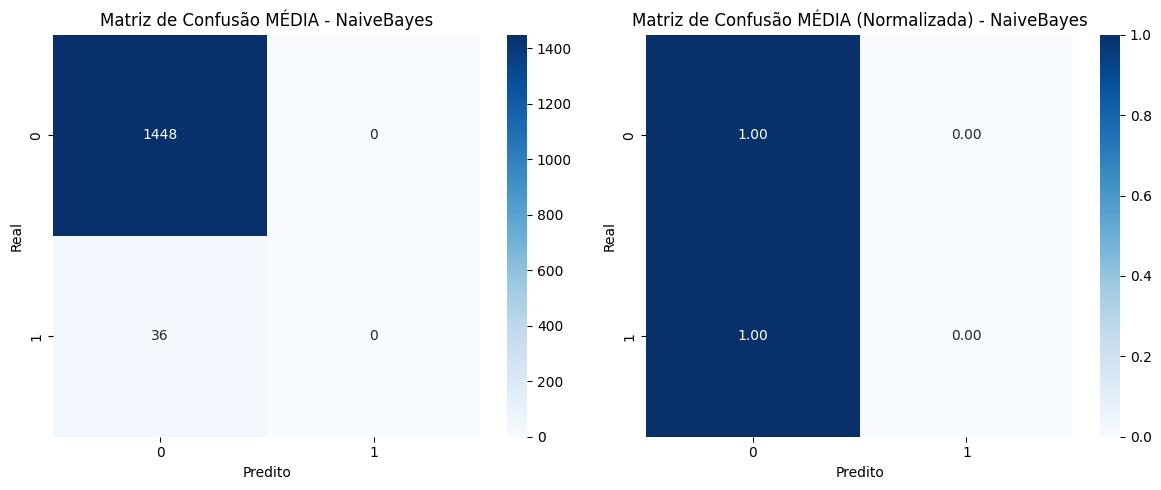

Folds RandomForest:   0%|          | 0/5 [00:00<?, ?it/s]

RandomForest | fold=fold_1 | Accuracy=0.976 | Precision=0.488 | Recall=0.500 | F1=0.494 | BalancedAccuracy=0.500 | GMean=0.000 | GMeanMicro=0.976 | AUPRC=0.543
RandomForest | fold=fold_2 | Accuracy=0.976 | Precision=0.488 | Recall=0.500 | F1=0.494 | BalancedAccuracy=0.500 | GMean=0.000 | GMeanMicro=0.976 | AUPRC=0.395
RandomForest | fold=fold_3 | Accuracy=0.976 | Precision=0.488 | Recall=0.500 | F1=0.494 | BalancedAccuracy=0.500 | GMean=0.000 | GMeanMicro=0.976 | AUPRC=0.477
RandomForest | fold=fold_4 | Accuracy=0.975 | Precision=0.488 | Recall=0.500 | F1=0.494 | BalancedAccuracy=0.500 | GMean=0.000 | GMeanMicro=0.975 | AUPRC=0.429
RandomForest | fold=fold_5 | Accuracy=0.975 | Precision=0.488 | Recall=0.500 | F1=0.494 | BalancedAccuracy=0.500 | GMean=0.000 | GMeanMicro=0.975 | AUPRC=0.484


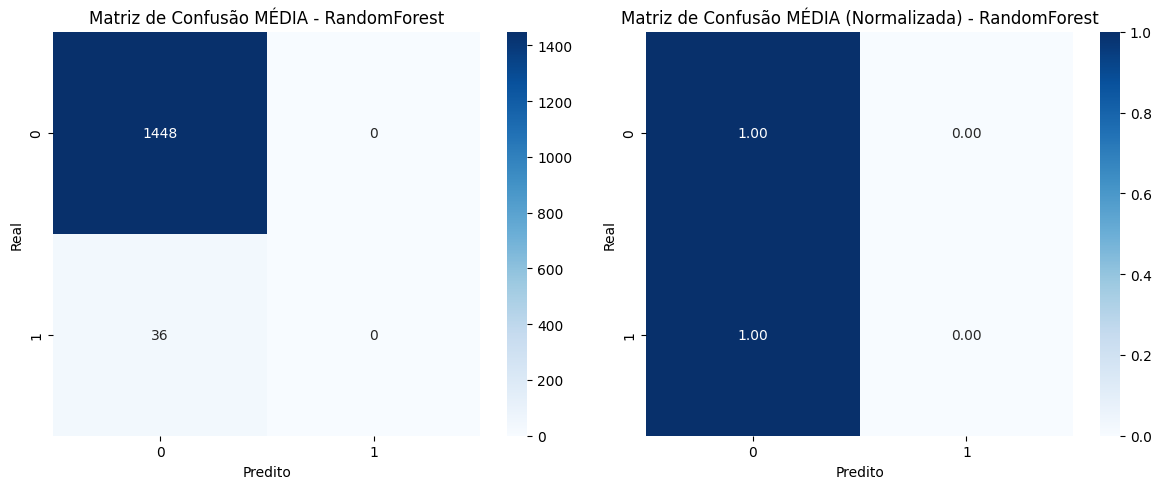

Folds LogisticRegression:   0%|          | 0/5 [00:00<?, ?it/s]

LogisticRegression | fold=fold_1 | Accuracy=0.976 | Precision=0.488 | Recall=0.500 | F1=0.494 | BalancedAccuracy=0.500 | GMean=0.000 | GMeanMicro=0.976 | AUPRC=0.759
LogisticRegression | fold=fold_2 | Accuracy=0.976 | Precision=0.488 | Recall=0.500 | F1=0.494 | BalancedAccuracy=0.500 | GMean=0.000 | GMeanMicro=0.976 | AUPRC=0.663
LogisticRegression | fold=fold_3 | Accuracy=0.976 | Precision=0.488 | Recall=0.500 | F1=0.494 | BalancedAccuracy=0.500 | GMean=0.000 | GMeanMicro=0.976 | AUPRC=0.681
LogisticRegression | fold=fold_4 | Accuracy=0.975 | Precision=0.488 | Recall=0.500 | F1=0.494 | BalancedAccuracy=0.500 | GMean=0.000 | GMeanMicro=0.975 | AUPRC=0.755
LogisticRegression | fold=fold_5 | Accuracy=0.975 | Precision=0.488 | Recall=0.500 | F1=0.494 | BalancedAccuracy=0.500 | GMean=0.000 | GMeanMicro=0.975 | AUPRC=0.608


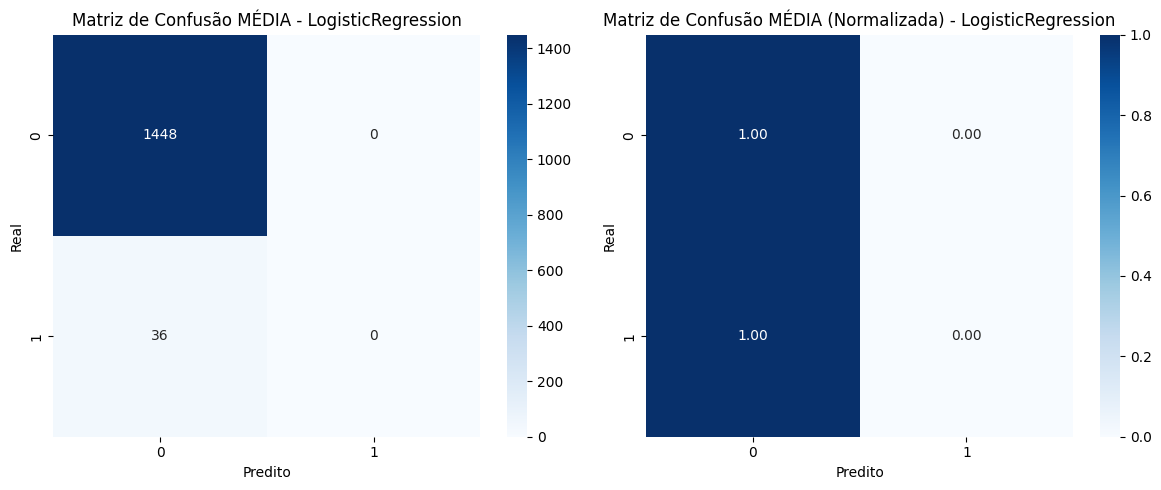

Folds LightGBM:   0%|          | 0/5 [00:00<?, ?it/s]

LightGBM | fold=fold_1 | Accuracy=0.985 | Precision=0.992 | Recall=0.681 | F1=0.761 | BalancedAccuracy=0.681 | GMean=0.601 | GMeanMicro=0.985 | AUPRC=0.688
LightGBM | fold=fold_2 | Accuracy=0.982 | Precision=0.898 | Recall=0.680 | F1=0.746 | BalancedAccuracy=0.680 | GMean=0.600 | GMeanMicro=0.982 | AUPRC=0.631
LightGBM | fold=fold_3 | Accuracy=0.980 | Precision=0.935 | Recall=0.611 | F1=0.673 | BalancedAccuracy=0.611 | GMean=0.471 | GMeanMicro=0.980 | AUPRC=0.686
LightGBM | fold=fold_4 | Accuracy=0.982 | Precision=0.991 | Recall=0.649 | F1=0.725 | BalancedAccuracy=0.649 | GMean=0.545 | GMeanMicro=0.982 | AUPRC=0.638
LightGBM | fold=fold_5 | Accuracy=0.978 | Precision=0.879 | Recall=0.594 | F1=0.647 | BalancedAccuracy=0.594 | GMean=0.435 | GMeanMicro=0.978 | AUPRC=0.599


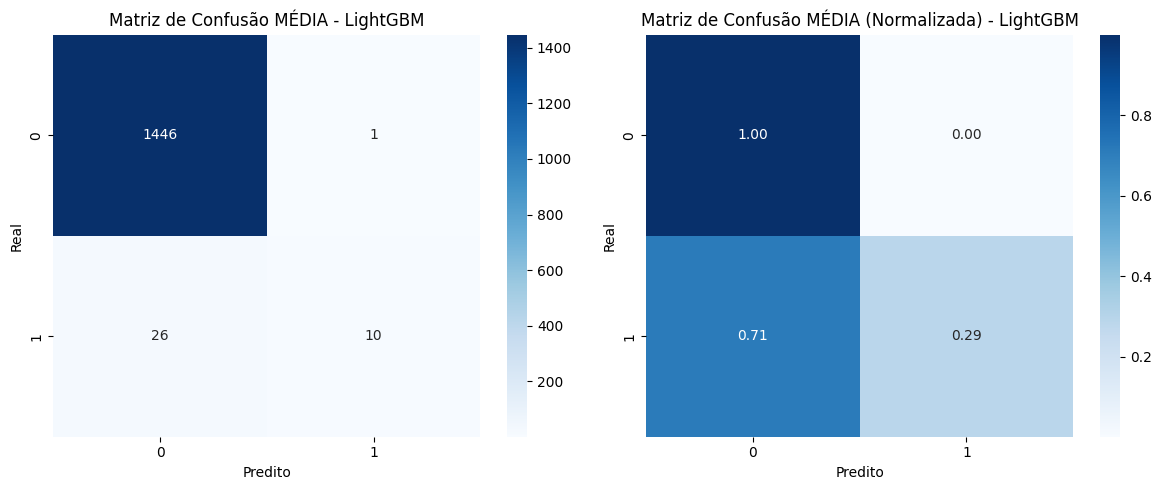

,Accuracy,Precision,Recall,F1,BalancedAccuracy,GMean,GMeanMicro,AUPRC,Modelo,Tempo_s
0,0.98,0.49,0.50,0.49,0.50,0.00,0.98,0.07,NaiveBayes,6.43
1,0.98,0.49,0.50,0.49,0.50,0.00,0.98,0.47,RandomForest,23.41
2,0.98,0.49,0.50,0.49,0.50,0.00,0.98,0.69,LogisticRegression,15.40
3,0.98,0.94,0.64,0.71,0.64,0.53,0.98,0.65,LightGBM,37.09


,Modelo,Accuracy,Precision,Recall,F1,BalancedAccuracy,GMean,GMeanMicro,AUPRC
0,NaiveBayes,0.98 (0.98-0.98) ± 0.00,0.49 (0.49-0.49) ± 0.00,0.50 (0.50-0.50) ± 0.00,0.49 (0.49-0.49) ± 0.00,0.50 (0.50-0.50) ± 0.00,0.00 (0.00-0.00) ± 0.00,0.98 (0.98-0.98) ± 0.00,0.07 (0.05-0.11) ± 0.02
1,RandomForest,0.98 (0.98-0.98) ± 0.00,0.49 (0.49-0.49) ± 0.00,0.50 (0.50-0.50) ± 0.00,0.49 (0.49-0.49) ± 0.00,0.50 (0.50-0.50) ± 0.00,0.00 (0.00-0.00) ± 0.00,0.98 (0.98-0.98) ± 0.00,0.47 (0.40-0.54) ± 0.06
2,LogisticRegression,0.98 (0.98-0.98) ± 0.00,0.49 (0.49-0.49) ± 0.00,0.50 (0.50-0.50) ± 0.00,0.49 (0.49-0.49) ± 0.00,0.50 (0.50-0.50) ± 0.00,0.00 (0.00-0.00) ± 0.00,0.98 (0.98-0.98) ± 0.00,0.69 (0.61-0.76) ± 0.06
3,LightGBM,0.98 (0.98-0.98) ± 0.00,0.94 (0.88-0.99) ± 0.05,0.64 (0.59-0.68) ± 0.04,0.71 (0.65-0.76) ± 0.05,0.64 (0.59-0.68) ± 0.04,0.53 (0.43-0.60) ± 0.08,0.98 (0.98-0.98) ± 0.00,0.65 (0.60-0.69) ± 0.04


In [6]:
metrics_df, metrics_summary = evaluate_models(df, seed=seed, use_class_weight=False, log_each_fold=True)

display(metrics_df)
display(metrics_summary)

# Class_weight Balanced
- Mais adequado para predizer a classe minoritária

Folds NaiveBayes:   0%|          | 0/5 [00:00<?, ?it/s]

NaiveBayes | fold=fold_1 | Accuracy=0.962 | Precision=0.687 | Recall=0.926 | F1=0.754 | BalancedAccuracy=0.926 | GMean=0.925 | GMeanMicro=0.962 | AUPRC=0.812
NaiveBayes | fold=fold_2 | Accuracy=0.958 | Precision=0.676 | Recall=0.938 | F1=0.745 | BalancedAccuracy=0.938 | GMean=0.937 | GMeanMicro=0.958 | AUPRC=0.684
NaiveBayes | fold=fold_3 | Accuracy=0.968 | Precision=0.705 | Recall=0.889 | F1=0.765 | BalancedAccuracy=0.889 | GMean=0.885 | GMeanMicro=0.968 | AUPRC=0.742
NaiveBayes | fold=fold_4 | Accuracy=0.952 | Precision=0.650 | Recall=0.844 | F1=0.704 | BalancedAccuracy=0.844 | GMean=0.836 | GMeanMicro=0.952 | AUPRC=0.711
NaiveBayes | fold=fold_5 | Accuracy=0.958 | Precision=0.672 | Recall=0.886 | F1=0.733 | BalancedAccuracy=0.886 | GMean=0.883 | GMeanMicro=0.958 | AUPRC=0.721


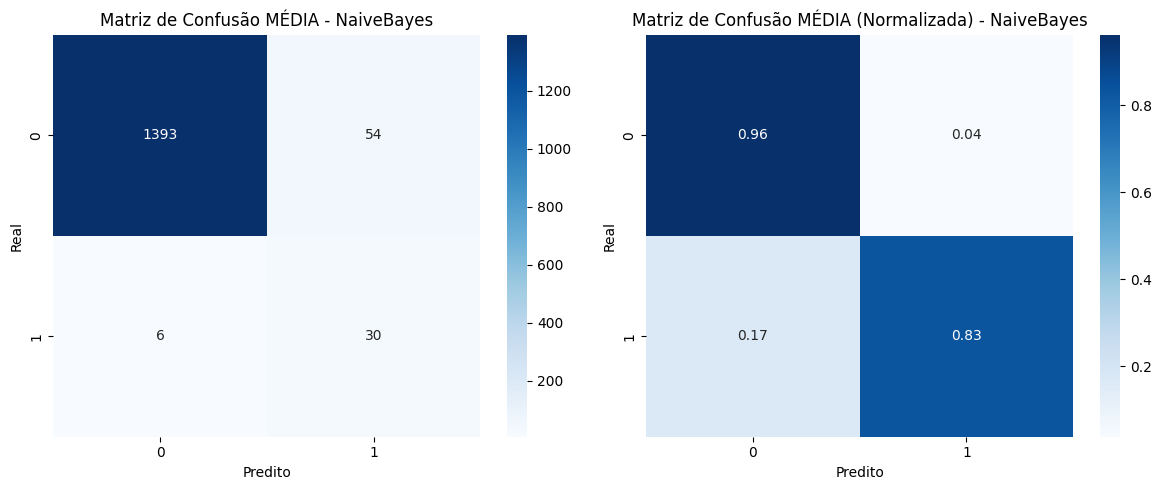

Folds RandomForest:   0%|          | 0/5 [00:00<?, ?it/s]

RandomForest | fold=fold_1 | Accuracy=0.976 | Precision=0.488 | Recall=0.500 | F1=0.494 | BalancedAccuracy=0.500 | GMean=0.000 | GMeanMicro=0.976 | AUPRC=0.710
RandomForest | fold=fold_2 | Accuracy=0.976 | Precision=0.488 | Recall=0.500 | F1=0.494 | BalancedAccuracy=0.500 | GMean=0.000 | GMeanMicro=0.976 | AUPRC=0.634
RandomForest | fold=fold_3 | Accuracy=0.976 | Precision=0.488 | Recall=0.500 | F1=0.494 | BalancedAccuracy=0.500 | GMean=0.000 | GMeanMicro=0.976 | AUPRC=0.634
RandomForest | fold=fold_4 | Accuracy=0.975 | Precision=0.488 | Recall=0.500 | F1=0.494 | BalancedAccuracy=0.500 | GMean=0.000 | GMeanMicro=0.975 | AUPRC=0.606
RandomForest | fold=fold_5 | Accuracy=0.975 | Precision=0.488 | Recall=0.500 | F1=0.494 | BalancedAccuracy=0.500 | GMean=0.000 | GMeanMicro=0.975 | AUPRC=0.606


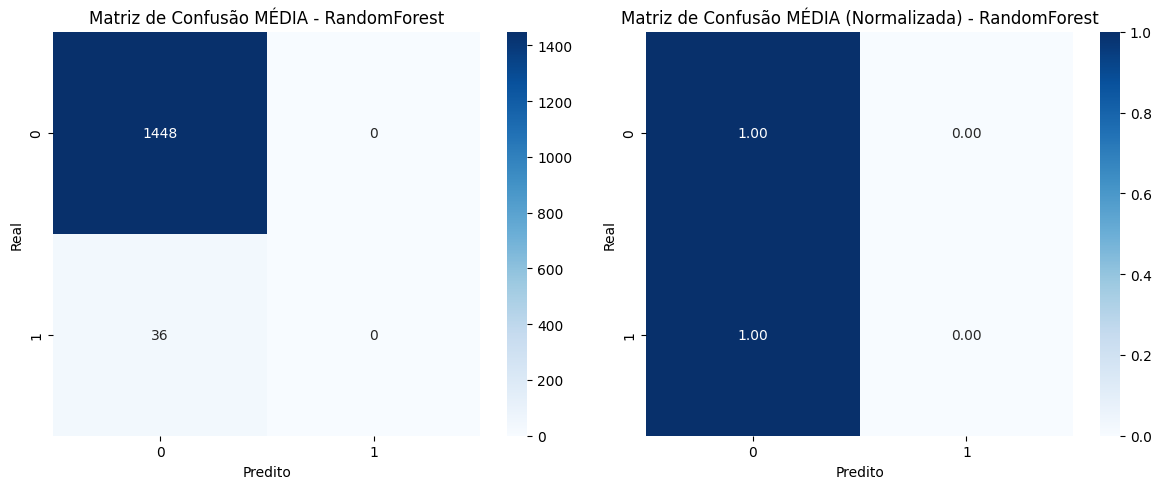

Folds LogisticRegression:   0%|          | 0/5 [00:00<?, ?it/s]

LogisticRegression | fold=fold_1 | Accuracy=0.987 | Precision=0.868 | Recall=0.858 | F1=0.863 | BalancedAccuracy=0.858 | GMean=0.847 | GMeanMicro=0.987 | AUPRC=0.793
LogisticRegression | fold=fold_2 | Accuracy=0.985 | Precision=0.839 | Recall=0.830 | F1=0.834 | BalancedAccuracy=0.830 | GMean=0.813 | GMeanMicro=0.985 | AUPRC=0.691
LogisticRegression | fold=fold_3 | Accuracy=0.985 | Precision=0.850 | Recall=0.802 | F1=0.824 | BalancedAccuracy=0.802 | GMean=0.779 | GMeanMicro=0.985 | AUPRC=0.733
LogisticRegression | fold=fold_4 | Accuracy=0.989 | Precision=0.886 | Recall=0.876 | F1=0.881 | BalancedAccuracy=0.876 | GMean=0.868 | GMeanMicro=0.989 | AUPRC=0.774
LogisticRegression | fold=fold_5 | Accuracy=0.983 | Precision=0.833 | Recall=0.807 | F1=0.820 | BalancedAccuracy=0.807 | GMean=0.785 | GMeanMicro=0.983 | AUPRC=0.680


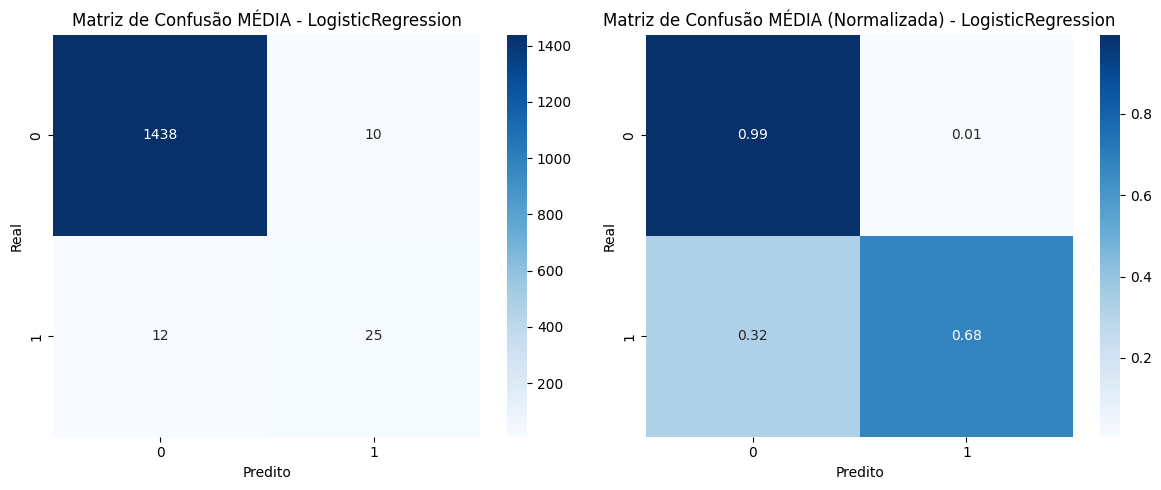

Folds LightGBM:   0%|          | 0/5 [00:00<?, ?it/s]

LightGBM | fold=fold_1 | Accuracy=0.985 | Precision=0.898 | Recall=0.735 | F1=0.794 | BalancedAccuracy=0.735 | GMean=0.686 | GMeanMicro=0.985 | AUPRC=0.654
LightGBM | fold=fold_2 | Accuracy=0.980 | Precision=0.834 | Recall=0.678 | F1=0.731 | BalancedAccuracy=0.678 | GMean=0.600 | GMeanMicro=0.980 | AUPRC=0.639
LightGBM | fold=fold_3 | Accuracy=0.983 | Precision=0.953 | Recall=0.666 | F1=0.741 | BalancedAccuracy=0.666 | GMean=0.577 | GMeanMicro=0.983 | AUPRC=0.651
LightGBM | fold=fold_4 | Accuracy=0.982 | Precision=0.898 | Recall=0.675 | F1=0.741 | BalancedAccuracy=0.675 | GMean=0.592 | GMeanMicro=0.982 | AUPRC=0.635
LightGBM | fold=fold_5 | Accuracy=0.983 | Precision=0.909 | Recall=0.702 | F1=0.768 | BalancedAccuracy=0.702 | GMean=0.636 | GMeanMicro=0.983 | AUPRC=0.590


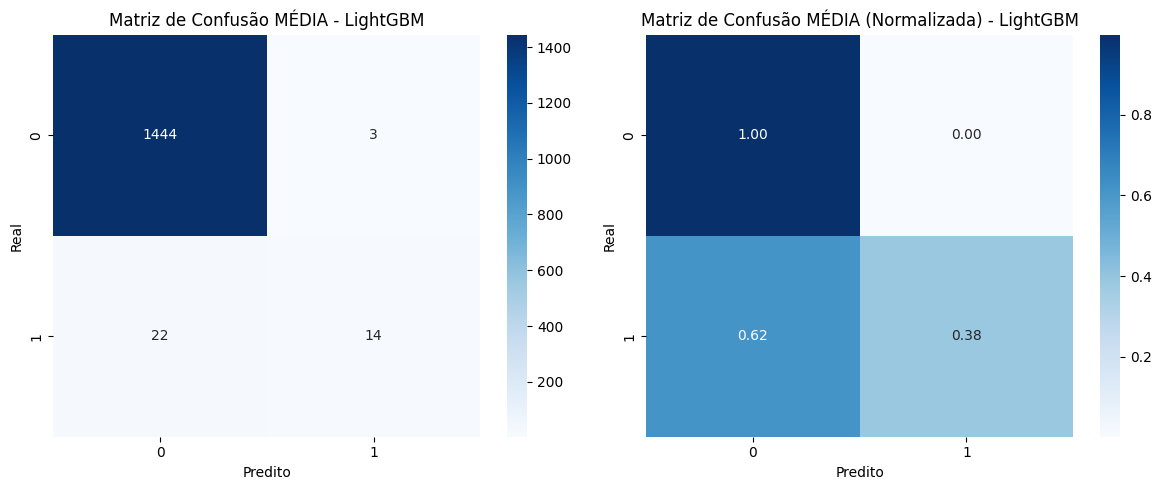

,Accuracy,Precision,Recall,F1,BalancedAccuracy,GMean,GMeanMicro,AUPRC,Modelo,Tempo_s
0,0.96,0.68,0.90,0.74,0.90,0.89,0.96,0.73,NaiveBayes,6.70
1,0.98,0.49,0.50,0.49,0.50,0.00,0.98,0.64,RandomForest,22.64
2,0.99,0.86,0.83,0.84,0.83,0.82,0.99,0.73,LogisticRegression,21.82
3,0.98,0.90,0.69,0.76,0.69,0.62,0.98,0.63,LightGBM,45.94


,Modelo,Accuracy,Precision,Recall,F1,BalancedAccuracy,GMean,GMeanMicro,AUPRC
0,NaiveBayes,0.96 (0.95-0.97) ± 0.01,0.68 (0.65-0.70) ± 0.02,0.90 (0.84-0.94) ± 0.04,0.74 (0.70-0.77) ± 0.02,0.90 (0.84-0.94) ± 0.04,0.89 (0.84-0.94) ± 0.04,0.96 (0.95-0.97) ± 0.01,0.73 (0.68-0.81) ± 0.05
1,RandomForest,0.98 (0.98-0.98) ± 0.00,0.49 (0.49-0.49) ± 0.00,0.50 (0.50-0.50) ± 0.00,0.49 (0.49-0.49) ± 0.00,0.50 (0.50-0.50) ± 0.00,0.00 (0.00-0.00) ± 0.00,0.98 (0.98-0.98) ± 0.00,0.64 (0.61-0.71) ± 0.04
2,LogisticRegression,0.99 (0.98-0.99) ± 0.00,0.86 (0.83-0.89) ± 0.02,0.83 (0.80-0.88) ± 0.03,0.84 (0.82-0.88) ± 0.03,0.83 (0.80-0.88) ± 0.03,0.82 (0.78-0.87) ± 0.04,0.99 (0.98-0.99) ± 0.00,0.73 (0.68-0.79) ± 0.05
3,LightGBM,0.98 (0.98-0.98) ± 0.00,0.90 (0.83-0.95) ± 0.04,0.69 (0.67-0.73) ± 0.03,0.76 (0.73-0.79) ± 0.03,0.69 (0.67-0.73) ± 0.03,0.62 (0.58-0.69) ± 0.04,0.98 (0.98-0.98) ± 0.00,0.63 (0.59-0.65) ± 0.03


In [7]:
metrics_df, metrics_summary = evaluate_models(df, seed=seed, use_class_weight=True, log_each_fold=True)

display(metrics_df)
display(metrics_summary)

# Considerações
## Sensibilidade
- O uso de class_weight revelou 3 modelos com resultados interessantes:
    - Naive Bayes (com um resultado de cara muito surpreendente acurácia balanceada)
    - Logistic Regression (Rápido e com precisão intermediária)
    - LightGBM (Para aplicações que precisam de alta precisão)

## Descarte
- O modelo RandomForest não desempenhou bem, e será descartado do estudo

# BaseLines

In [8]:
# Abordagem textual
df_test = pd.read_csv(os.path.join(split_path, 'test_set.csv'))
print(f'shape inicial: {df_test.shape}')

df_test = essencial_columns(df_test)
display(df_test.head(1))

# remove_col_fold
df_test.drop(columns=['fold'], inplace=True)
display(df_test.head())
df_test['label'].value_counts()

shape inicial: (1484, 7)


,text,fold,label
0,a wizard of earthsea ged is a young boy on gon...,test,0


,text,label
0,a wizard of earthsea ged is a young boy on gon...,0
1,blade runner 3 replicant night living on mars ...,0
2,the metamorphosis one day gregor samsa a trave...,0
3,farmer giles of ham farmer giles aegidius ahen...,0
4,gone with the wind gone with the wind takes pl...,0


label
0    1447
1      37
Name: count, dtype: int64

In [9]:
def evaluate_on_test(train_df, test_df, seed, use_class_weight=False):
    labels_sorted = np.array(sorted(train_df['label'].unique()))

    models = {
        "NaiveBayes": MultinomialNB(),
        "LogisticRegression": LogisticRegression(
            random_state=seed, **({"class_weight": "balanced"} if use_class_weight else {})
        ),
        "LightGBM": lgb.LGBMClassifier(
            random_state=seed, verbosity=-1, **({"class_weight": "balanced"} if use_class_weight else {})
        ),
    }

    results = []

    X_train_text = train_df['text'].astype(str).values
    y_train = train_df['label'].values
    X_test_text = test_df['text'].astype(str).values
    y_test = test_df['label'].values

    for model_name, model in models.items():
        # TF-IDF no treino inteiro
        vect = TfidfVectorizer()
        X_train = vect.fit_transform(X_train_text)
        X_test = vect.transform(X_test_text)

        # pesos só no NaiveBayes se solicitado
        if use_class_weight and model_name == "NaiveBayes":
            sw = compute_sample_weight(class_weight="balanced", y=y_train)
            model.fit(X_train, y_train, sample_weight=sw)
        else:
            model.fit(X_train, y_train)

        preds = model.predict(X_test)
        proba = model.predict_proba(X_test)

        metrics = {
            "Modelo": model_name,
            "Accuracy": accuracy_score(y_test, preds),
            "Precision": precision_score(y_test, preds, average="macro", zero_division=0),
            "Recall": recall_score(y_test, preds, average="macro", zero_division=0),
            "F1": f1_score(y_test, preds, average="macro", zero_division=0),
            "BalancedAccuracy": balanced_accuracy_score(y_test, preds),
            "GMean": geometric_mean_score(y_test, preds, average="binary"),
            "GMeanMicro": geometric_mean_score(y_test, preds, average="micro"),
            "AUPRC": average_precision_score(y_test, proba[:, 1])
        }
        results.append(metrics)

        # matrizes de confusão lado a lado
        cm = confusion_matrix(y_test, preds, labels=labels_sorted)
        cmn = confusion_matrix(y_test, preds, labels=labels_sorted, normalize="true")

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=labels_sorted, yticklabels=labels_sorted, ax=axes[0])
        axes[0].set_xlabel("Predito"); axes[0].set_ylabel("Real")
        axes[0].set_title(f"Matriz de Confusão - {model_name}")

        sns.heatmap(cmn, annot=True, fmt=".2f", cmap="Blues",
                    xticklabels=labels_sorted, yticklabels=labels_sorted, ax=axes[1])
        axes[1].set_xlabel("Predito"); axes[1].set_ylabel("Real")
        axes[1].set_title(f"Matriz de Confusão (Normalizada) - {model_name}")

        plt.tight_layout()
        plt.show()

    return pd.DataFrame(results).round(2)


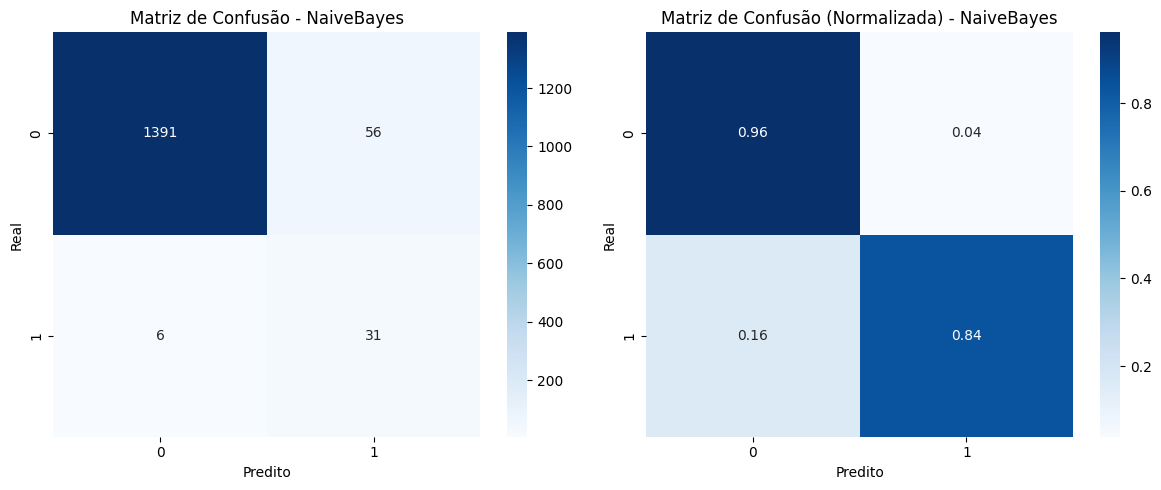

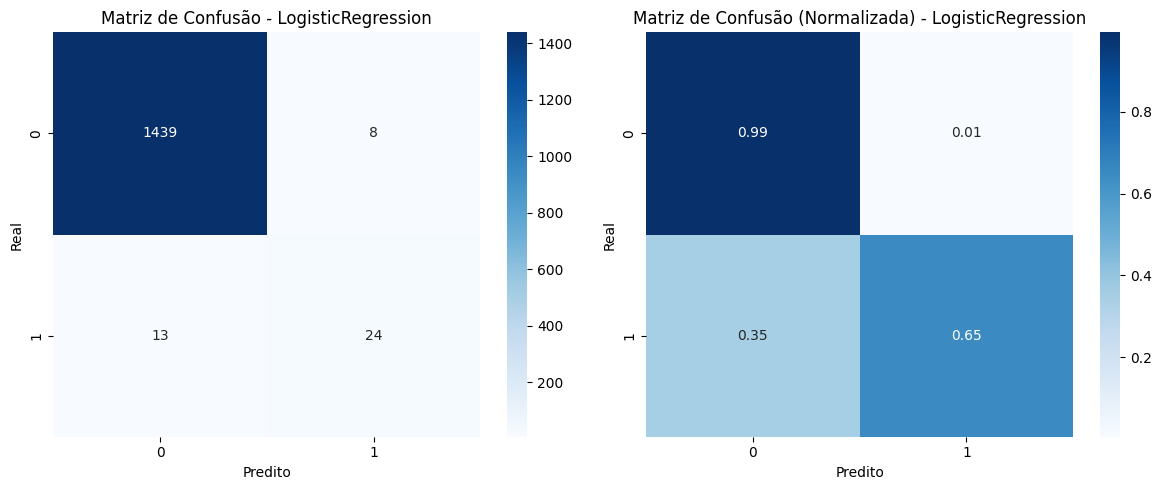

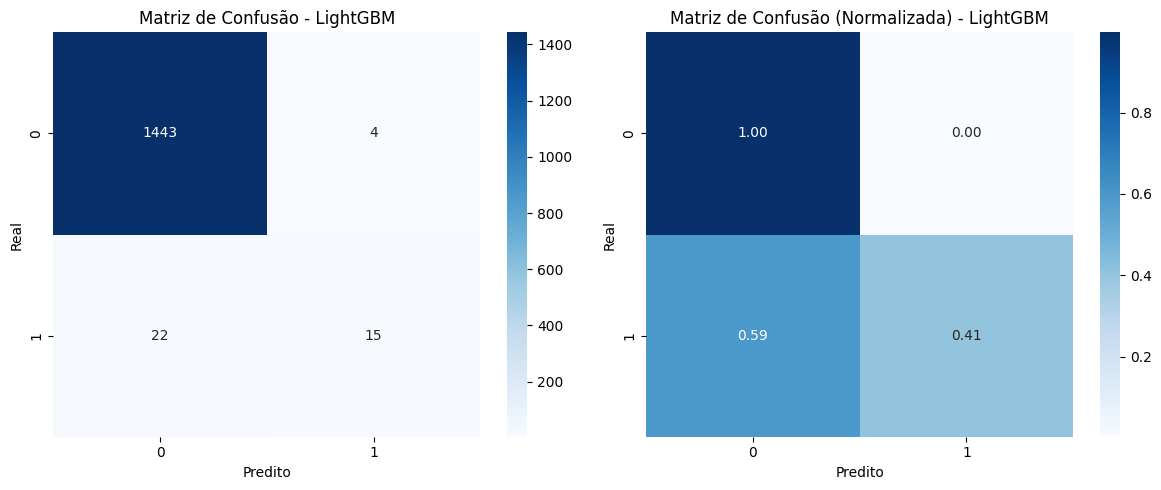

,Modelo,Accuracy,Precision,Recall,F1,BalancedAccuracy,GMean,GMeanMicro,AUPRC
0,NaiveBayes,0.96,0.68,0.90,0.74,0.90,0.90,0.96,0.64
1,LogisticRegression,0.99,0.87,0.82,0.84,0.82,0.80,0.99,0.64
2,LightGBM,0.98,0.89,0.70,0.76,0.70,0.64,0.98,0.61


In [10]:
metrics_test = evaluate_on_test(df, df_test, seed=seed, use_class_weight=True)

display(metrics_test)

In [11]:
# Resultados coerentes com CV
metrics_summary = metrics_summary.drop(index=[1])
metrics_summary

,Modelo,Accuracy,Precision,Recall,F1,BalancedAccuracy,GMean,GMeanMicro,AUPRC
0,NaiveBayes,0.96 (0.95-0.97) ± 0.01,0.68 (0.65-0.70) ± 0.02,0.90 (0.84-0.94) ± 0.04,0.74 (0.70-0.77) ± 0.02,0.90 (0.84-0.94) ± 0.04,0.89 (0.84-0.94) ± 0.04,0.96 (0.95-0.97) ± 0.01,0.73 (0.68-0.81) ± 0.05
2,LogisticRegression,0.99 (0.98-0.99) ± 0.00,0.86 (0.83-0.89) ± 0.02,0.83 (0.80-0.88) ± 0.03,0.84 (0.82-0.88) ± 0.03,0.83 (0.80-0.88) ± 0.03,0.82 (0.78-0.87) ± 0.04,0.99 (0.98-0.99) ± 0.00,0.73 (0.68-0.79) ± 0.05
3,LightGBM,0.98 (0.98-0.98) ± 0.00,0.90 (0.83-0.95) ± 0.04,0.69 (0.67-0.73) ± 0.03,0.76 (0.73-0.79) ± 0.03,0.69 (0.67-0.73) ± 0.03,0.62 (0.58-0.69) ± 0.04,0.98 (0.98-0.98) ± 0.00,0.63 (0.59-0.65) ± 0.03


# Save Results

In [12]:
path_baseline_results = '../results/baseline'
os.makedirs(path_baseline_results, exist_ok=True)

metrics_summary.to_csv(f'{path_baseline_results}/cv_baseline.csv', index=False)
metrics_test.to_csv(f'{path_baseline_results}/test_baseline.csv', index=False)